# Mimicking RouteLLM

### Generate embeddings

In [8]:
import os
import json
import requests
import numpy as np

results_path = '../AutoFL/results/d4j_autofl_eol_1/llama3'
initial_prompts_path = 'route_data/initial_prompts.json'
endpoint = 'http://localhost:11434/api/embeddings'
embeddings_path = 'route_data/embeddings.json'

In [2]:
initial_prompt_dict = dict()
for file in sorted(os.listdir(results_path)):
    with open(os.path.join(results_path, file)) as f:
        msgs = json.load(f)['messages']
        bug_id = file[4:-5]
        initial_prompt = msgs[0]['content'] + msgs[1]['content']
        initial_prompt_dict[bug_id] = initial_prompt

# with open(initial_prompts_path, 'w') as f:
#     json.dump(initial_prompt_dict, f, indent=4)

In [ ]:
def _query_model(payload):
    for _ in range(5):
        try:
            json_payload = json.dumps(payload)
            headers = {'Content-Type': 'application/json'}
            response = json.loads(requests.post(endpoint, data=json_payload, headers=headers).text)
            return response['embedding']
        except Exception as e:
            save_err = e
            if "The server had an error processing your request." in str(e):
                time.sleep(1)
            else:
                break
    raise save_err


def get_LLM_response(initial_prompt):
    payload = {
        'model': 'nomic-embed-text',
        'prompt': initial_prompt,
        'stream': False
    }
    return _query_model(payload)

if __name__ == "__main__":
    embeddings_dict = dict()
    with open(initial_prompts_path) as f:
        data = json.load(f)
        
    for bug_id in data:
        initial_prompt = data[bug_id]
        embedding = get_LLM_response(initial_prompt)
        embeddings_dict[bug_id] = embedding
    
    with open(embeddings_path, 'w') as f:
        json.dump(embeddings_dict, f)

### Format vs. results

In [ ]:
## gpt-4o vs. llama3 config
strong_result_path = '../AutoFL/combined_fl_results/d4j_gpt4o_results_R10_full.json'
weak_result_path = '../AutoFL/combined_fl_results/d4j_eol_llama3_R10.json'
vs_data_path = 'route_data/vs.json'
filtered_embeddings_path = 'route_data/embeddings.npy'

In [15]:
strong_model_name = 'llama3.1-8b'
weak_model_name = 'llama3-8b'
strong_result_path = '../AutoFL/combined_fl_results/d4j_eol_llama3.1_R5.json'
weak_result_path = '../AutoFL/combined_fl_results/d4j_eol_llama3_R5.json'

vs_data_path = f'route_data/{strong_model_name}_vs_{weak_model_name}.json'
filtered_embeddings_path = f'route_data/{strong_model_name}_{weak_model_name}_embeddings.npy'

In [ ]:
with open(strong_result_path) as f:
    strong_result = json.load(f)['buggy_methods']

with open(weak_result_path) as f:
    weak_result = json.load(f)['buggy_methods']

def extract_min_ranks(result, bug_list):
    min_ranks = list() 
    for bug_id in bug_list:
        buggy_methods = result[bug_id]
        min_ranks.append(0 if not buggy_methods else min(map(lambda x: x['autofl_rank'], buggy_methods.values())))
    
    return min_ranks    

sorted_bug_list = sorted(strong_result.keys())

strong_ranks = extract_min_ranks(strong_result, sorted_bug_list)
weak_ranks = extract_min_ranks(weak_result, sorted_bug_list)
vs_result = list(map(lambda x: x[0] < x[1], zip(strong_ranks, weak_ranks)))
vs_data = list()

for i, bug_id in enumerate(sorted_bug_list):
    vs_data.append({
        "model_a": strong_model_name,
        "model_b": weak_model_name,
        "idx": i,
        "winner": "model_a" if vs_result[i] else "model_b"
    })

with open(vs_data_path, 'w') as f:
    json.dump(vs_data, f, indent=4)

with open(embeddings_path) as f:
    embeddings = json.load(f)
filtered_embeddings = np.array([embeddings[bug_id] for bug_id in sorted_bug_list])
np.save(filtered_embeddings_path, filtered_embeddings)

### How to use?

In [ ]:
# ck_path = 'routers/matrix_factorization/best_checkpoint.pt'

# from routers.routers import MatrixFactorizationRouter
# router = MatrixFactorizationRouter(ck_path, strong_model='gpt-4o', weak_model='llama3-8b')

# router.calculate_strong_win_rate("You are a debugging assistant. You will be presented with a failing test, and tools (functions) to access the source code of the system under test (SUT). Your task is to provide a step-by-step explanation of how the bug occurred, based on the failing test and the information you retrieved using tools about the SUT. You will be given 9 chances to interact with functions to gather relevant information. An example answer would look like follows.\n\n```\nThe test `testGenerateURLFragment` checks whether HTML entities such as `&quot;` are correctly escaped to their corresponding character by the `StandardToolTipTagFragmentGenerator.generateToolTipFragment` method. However, the test failure indicates that this is not the case. Following the execution path, we find that `StandardToolTipTagFragmentGenerator.generateToolTipFragment` is not escaping any HTML code; instead, it is using its input `toolTipText` as is. Consequently, un-escaped strings are being returned, which leads to the error demonstrated by the test.\n```\n\nYou have the following functions available to debug the case:\n\n1. get_failing_tests_covered_methods_for_class(class_name) - This function takes a class_name as input and returns a list of method names covered by failing tests for the specified class in the program under test. It returns a list of truncated method signatures (add to the class name to get the full signature). Call example: get_failing_tests_covered_methods_for_class(\"my.favorite.Class\")\n2. get_code_snippet(method_signature) - This function takes a signature as input and returns the corresponding code snippet for the method or field. It returns the code snippet for the specified method or field, or the error message if the signature is not found. Call example: get_code_snippet(\"my.favorite.Class.Method(Args)\")\n3. get_comments(method_signature) - This function takes a signature as input and returns JavaDoc documentation (if available) for the method or field. It returns the comment/documentation for the specified method or field, or the error message if the signature is not found. Call example: get_comments(\"my.favorite.Class.Method(Args)\")\n\nTo make a function call, respond like the following:\n\n```\nFunction call: get_code_snippet(\"my.favorite.Class.Method(Args)\")\n```\n\nIf you are done and ready to generate a response, respond like the following:\n\n```\nConclusion: The test `testGenerateURLFragment` checks...\n```\n\nYou will keep these instructions in mind while proceeding.\n\nAfter providing this diagnosis, you will be prompted to suggest which methods would be the best locations to be fixed. The answers should be in the form of `ClassName.MethodName(ArgType1, ArgType2, ...)` without commentary (one per line), as your answer will be automatically processed before finally being presented to the user.The test `['org.jfree.chart.renderer.category.junit.AbstractCategoryItemRendererTests.test2947660()']` failed.\nThe test looks like:\n\n```java\n396 :     public void test2947660() {\n397 :         AbstractCategoryItemRenderer r = new LineAndShapeRenderer();\n400 : \n401 :         DefaultCategoryDataset dataset = new DefaultCategoryDataset();\n402 :         CategoryPlot plot = new CategoryPlot();\n403 :         plot.setDataset(dataset);\n404 :         plot.setRenderer(r);\n406 : \n407 :         dataset.addValue(1.0, \"S1\", \"C1\");\n408 :         LegendItemCollection lic = r.getLegendItems();\n409 :         assertEquals(1, lic.getItemCount()); // error occurred here\n411 :     }\n```\n\nIt failed with the following error message and call stack:\n\n```\njunit.framework.AssertionFailedError: expected:<1> but was:<0>\n\tat org.jfree.chart.renderer.category.junit.AbstractCategoryItemRendererTests.test2947660(AbstractCategoryItemRendererTests.java:409)\n```\n\nStart by calling the `get_failing_tests_covered_classes` function.")

/Users/hyunjoon/anaconda3/envs/route/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Analysis

In [18]:
probs_dir = f'results/cv/{strong_model_name}_{weak_model_name}'
probs = dict()
for i in range(1, 6):
    with open(f'{probs_dir}/fold_{i}.json') as f:
        data = json.load(f)
    probs.update(data)
len(probs)

353

(array([14., 27., 32., 91., 65., 51., 63.,  5.,  3.,  2.]),
 array([0.33058831, 0.3404984 , 0.35040849, 0.36031859, 0.37022868,
        0.38013877, 0.39004886, 0.39995895, 0.40986905, 0.41977914,
        0.42968923]),
 <BarContainer object of 10 artists>)

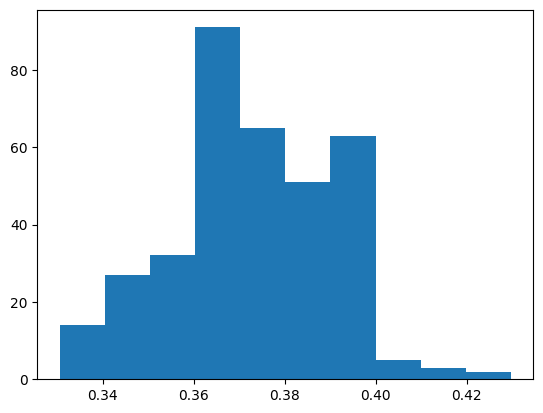

In [19]:
import matplotlib.pyplot as plt
plt.hist(probs.values())

In [26]:
weak_count = len(list(filter(lambda x: x == 1, weak_ranks)))
weak_count

104

In [27]:
strong_count = len(list(filter(lambda x: x == 1, strong_ranks)))
strong_count

106

In [ ]:
len(list(filter(lambda x: x[0] == 1 and x[1] != 1, zip(weak_ranks, strong_ranks)))) # Weak model correct, while Strong model incorrect

39

In [23]:
weak_key_list = list(weak_result.keys())

def acc_at_1_and_weak_model_calls_for_threshold(threshold):
    aggregated_ranks = list()
    weak_model_count = 0
    for i, bug_id in enumerate(strong_result):
        if probs[bug_id] > threshold:
            aggregated_ranks.append(strong_ranks[i])
        else:
            aggregated_ranks.append(weak_ranks[i])
            weak_model_count += 1
    return len(list(filter(lambda x: x == 1, aggregated_ranks))), weak_model_count

In [24]:
list_of_acc_at_1 = list()
weak_model_calls = list()

for i in range(20 + 1):
    threshold = 0.05 * i
    acc_at_1, weak_model = acc_at_1_and_weak_model_calls_for_threshold(threshold)
    list_of_acc_at_1.append(acc_at_1)
    weak_model_calls.append(1 - (weak_model / len(weak_ranks)))

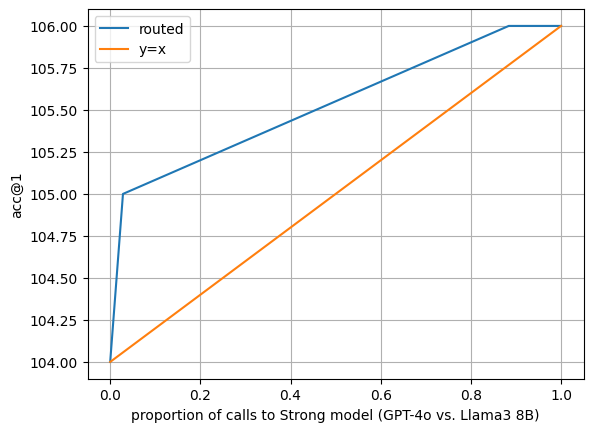

In [ ]:
plt.plot(weak_model_calls, list_of_acc_at_1, label='routed')
plt.plot([0.0, 1.0], [weak_count, strong_count], label='y=x')
plt.xlabel(f"proportion of calls to Strong model ({strong_model_name} vs. {weak_model_name})")
plt.ylabel("acc@1")
plt.grid(True)
plt.legend()
plt.show()